# **Домашнее задание #3**

**Задачи:**
- Дообучить выбранную модель продоложать текст;
- Рассмотреть варианты семплирования.

# **0. Настроим рабочее пространство.**

In [ ]:
# !pip install pandas==2.2.2 --force-reinstall


In [ ]:
# !pip install -U corus==0.10.0 tiktoken==0.10.0 youtokentome==1.0.6 sentence_transformers==5.0.0 numpy==2.0.2 matplotlib==3.10.0 transformers==4.55.0 datasets==4.0.0 torch==2.6.0+cu124 accelerate>=1.1.0 huggingface-hub ipywidgets jupyter

In [ ]:
from typing import Optional, List

import pandas as pd
import numpy as np

# from corus import load_lenta          # ---- то работает то не работает, так что просто загрузим через pandas
from datasets import Dataset
from datasets import load_dataset

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

import transformers.pipelines as _pipelines
from transformers import AutoConfig
from transformers import AutoTokenizer
from transformers import pipeline
from transformers import AutoModelForCausalLM, Trainer, TrainingArguments
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import EarlyStoppingCallback
from transformers import DataCollatorForLanguageModeling # 1) Добавляет нули и 2) cам создаёт labels (следующие слова, которые предсказывает)

from tqdm import tqdm
import math
import random

In [ ]:
pd.set_option('display.max_colwidth', None)  # макс.широкий столбец в датафрейме

_pipelines.torch = torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# **Задание 1. Подготовка данных и модели** — 2 балла

## **1.1. Выбор и загрузка датасета** — 0.5 балла


Выберем и загрузим корпус новостей Lenta.ru для задачи генерации текста.

In [ ]:
%%capture
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

## **1.2. Сформируем удобный датафрейм**

In [ ]:
# Загрузка данных
df = pd.read_csv('lenta-ru-news.csv.gz', compression='gzip')

# Проверка структуры
df.head()

,url,title,text,topic,tags
0,https://lenta.ru/news/2018/12/14/cancer/,Названы регионы России с самой высокой смертностью от рака,"Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онкологические заболевания становились причиной смерти в Псковской, Тверской, Тульской и Орловской областях, а также в Севастополе. Вице-премьер напомнила, что главные факторы смертности в России — рак и болезни системы кровообращения. В начале года стало известно, что смертность от онкологических заболеваний среди россиян снизилась впервые за три года. По данным Росстата, в 2017 году от рака умерли 289 тысяч человек. Это на 3,5 процента меньше, чем годом ранее.",Россия,Общество
1,https://lenta.ru/news/2018/12/15/doping/,Австрия не представила доказательств вины российских биатлонистов,"Австрийские правоохранительные органы не представили доказательств нарушения российскими биатлонистами антидопинговых правил. Об этом сообщил посол России в Вене Дмитрий Любинский по итогам встречи уполномоченного адвоката дипмиссии с представителями прокуратуры страны, передает ТАСС. «Действует презумпция невиновности. Каких-либо ограничений свободы передвижения для команды нет», — добавили в посольстве. Международный союз биатлонистов (IBU) также не будет применять санкции к российским биатлонистам. Все они продолжат выступление на Кубке мира. Полиция нагрянула в отель сборной России в Хохфильцене вечером 12 декабря. Как написал биатлонист Александр Логинов, их считают виновными в махинациях с переливанием крови. Биатлонисту Антону Шипулину, также попавшему в список, полиция нанесла отдельный визит: сейчас он тренируется отдельно в австрийском Обертиллахе. Обвинения спортсмен назвал бредом, а также указал на «охоту на ведьм» в мировом биатлоне. В Австрии прием допинга — уголовное преступление. Максимальное наказание за его употребление — три года тюрьмы.",Спорт,Зимние виды
2,https://lenta.ru/news/2018/12/15/disneyland/,Обнаружено самое счастливое место на планете,"Сотрудники социальной сети Instagram проанализировали поставленные пользователями смайлики, геолокации и хештеги и опубликовали итоги 2018 года. Об этом сообщается на официальном сайте Instagram. Таким образом, самой счастливой геолокацией Instagram признал Диснейленд в Токио, так как больше всего счастливых смайликов в 2018 году пользователи ставили именно под фотографиями из японского Диснейленда. Также эксперты назвали самый популярный фильтр для лица: им стал фильтр с сердечками на глазах. А, например, самыми часто используемыми хештегами в 2018 году были #metoo, #timesup и #marchforourlives. В ноябре сотрудники британской ассоциации потребителей Which? составили рейтинг самых безопасных стран для путешествий. Специалисты проанализировали 20 самых популярных туристических направлений по четырем критериям: уровень преступности, угроза здоровью, вероятность теракта и стихийных бедствий. Самой безопасной страной по всем параметрам стала Исландия.",Путешествия,Мир
3,https://lenta.ru/news/2018/12/15/usa25/,В США раскрыли сумму расходов на расследование «российского дела»,"С начала расследования российского вмешательства в выборы власти США потратили более 25 миллионов долларов. Об этом сообщает Associated Press со ссылкой на отчет Министерства юстиции США. В документе содержатся данные о расходах на следствие с апреля по сентябрь 2018 года. За эти полгода было потрачено 4,6 миллиона долларов, из которых почти 3 миллиона долларов ушли на зарплату сотрудников, 580 тысяч — на поездки и сопутствующие расходы. Ранее Минюст США уже публиковал отчеты о затратах на дело о российском вмешательстве за предыдущие месяцы. 11 декабря расследование спецпрокурора Робера Мюллера показало, что по меньшей мере 14 человек из окружения президента США Дональда Трампа контактировали с россиянами во время его избирательной кампании и последующего переходного периода перед вступлением в до

In [ ]:
df.shape

(739351, 5)

## **1.3. Ограничение размерности датасета**

In [ ]:
df = df[:15_000]

In [ ]:
# Конвертируем в Dataset, чтобы пользоваться всеми преимуществами библиотеки Transformers
dataset = Dataset.from_pandas(df)

## **1.4. Выбор предобученной модели** — 0.5 балла

Нам необходимо выбрать подходящую предобученную модель до 350 млн параметров на Hugging Face Model Hub. Такие сравнительно небольшие модели, вероятно простые, и еще не предназначены для выполнения инструкций и поставленных задач.



---


**Как правильно выбрать модель?**

При выборе модели следует руководствоваться описанием в карточке, а также попытаться расшифровать само название модели.

> `"RuGPT-3 Small is a GPT-2 based model trained on Russian language corpus"`

 Прочитав, название модели и заглянув в карточку, следует понять, что данная модель  обучена не на выполнение инструкций, а просто на продолжение текста ("Свобода - это...") , на это могут указывать следующие маркеры:

- gpt, gpt2, gpt3, rugpt;
- trained on Russian language corpus),
- тренировона на Wikipedia, книги, новости.
- "This model is trained for text generation..."
- "Causal language model..."
- "Pretrained on Russian corpus..."


Признаки, которые указывают, что модели направлены на выполнение инструкций ("Напиши новость о том, что..."):

- instruct, chat, saiga, vikhr
- tuned, aligned, rlhf
- Trained on: Alpaca, ShareGPT, FLAN
- "Fine-tuned for instruction following..."
- "Chat model..."
- "Trained on instruction datasets..."
- "RLHF aligned..."



---





**Наш выбор модели:**  **`ai-forever/rugpt3small_based_on_gpt2`**

**ВАЖНАЯ ОСОБЕННОСТЬ**: Такая сравнительно небольшая модель (125 млн параметров) способна только продолжать текст (начало фразы...), а не следовать инструкциям и выполнять задания:
- модель не умеет выполнять инструкции и задания ("Напиши новость о том, что...")
- задается начало текста, которое модель продоложает ("В России всё очень хорошо...")

Модели, которые способны выполнять задания инструкции весят в разы больше.

**Основные источники данных выбранной `ai-forever/rugpt3small_based_on_gpt2`:**

- `Википедия` - русскоязычные статьи
- `Новости` - тексты российских новостных сайтов
- `Художественная литература` - классическая и современная русская литература
- `Научные тексты` - академические публикации на русском языке
- `Веб-тексты` - качественные тексты с русскоязычных сайтов
- `Социальные сети` - отфильтрованные тексты из соцсетей

**Характеристики датасета модели:**

- **Объем:** ~15GB текста
- **Токены:** ~2.7 миллиарда токенов
- **Период:** тексты до 2020 года
- **Фильтрация:** удалены низкокачественные и дублированные тексты

**Особенности модели:**

- **Размер:** 125M параметров (small версия)
- Модель основана на архитектуре GPT-2
- Адаптирована для русского языка
- Поддерживает различные стили текста: формальный, разговорный, художественный

Эта модель хорошо подходит для генерации русскоязычного текста, но может отражать предвзятости, присутствующие в обучающих данных.

## **1.5. Предварительная обработка данных** - 1 балл

Предварительно обработаем наши данные.

Обращаем внимание, что мы решаем задачу генерации  текста, а значит текст должен быть максимально похож на естественное человесеское изложение, поэтому мы откажемся от таких методов предобработки как:

- нормализации регистров символов;
- удаления стоп-слов;
- и ненужных знаков препинания.

В качестве предобработки используем только:

- токенизацию.

Но перед этим определим максимальную длину контекста.

### **1.5.1 Выбор оптимальной длины контекста (context_length)**

Длину контекста важно определить, чтобы оптимизировать ресурсы на обучение.

**Длина контекста** - максимальное количество токенов, которые поедается на вход модели. Она зависит от двух факторов:

- Размер памяти GPU
- Требования задачи

В карточке модели указано, что модель обучена на текстах длиной до 1024 токенов, а дообучена на текстах до 2048 токенов.

Проверим это через `AutoConfig`

In [ ]:
config = AutoConfig.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")

# Получаем максимальную длину контекста
max_context_length = config.max_position_embeddings
print(f"Максимальная длина контекста в модели: {max_context_length}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Максимальная длина контекста в модели: 2048


Так как мы собираемся генерировать новости, для начала определим среднюю длину одной новости из обучающего корпуса текстов.

In [ ]:
context_len = df['text'].apply(lambda x: len(x.split())).mean()
optimal_context_len = round(context_len * 2)
print(f'- Средняя длина одного текста {context_len} слов.')
print(f'- Умножим это значение на среднюю длину слова в русском языке в 1.5-2 токена.')
print(f'- Получим оптимальную длину контекста {optimal_context_len} токенов.')


- Средняя длина одного текста 179.49433333333334 слов.
- Умножим это значение на среднюю длину слова в русском языке в 1.5-2 токена.
- Получим оптимальную длину контекста 359 токенов.


**Таким образом, выставляем оптимальную длину контекста = 359.**

In [ ]:
context_length = optimal_context_len

### **1.5.2 Токенизация**

Токенайзер нужен для ДВУХ разных задач:
1) Для обучения (преобразует датасет в токены для обучения - наша функция `tokenize()`)
2) Для генерации (после обучения)

Один и тот же токенайзер, но используется в разных местах для разных целей.

Каждая модель имеет свой собственный токенизатор, предназначенный специально для неё.

При создании токенизатора с помощью метода `AutoTokenizer.from_pretrained()` библиотека автоматически загружает правильный токенизатор, соответствующий указанной модели. Таким образом, токенизатор настраивается на работу именно с этой моделью.

При токенизации важно:
- определить наиболее подходящий метод токенизации
- оценить качество токенизации

Загрузим токенизатор.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")
tokenizer.pad_token = tokenizer.eos_token  # Настройка pad_token

Токенайзер НЕ меняется при обучении, поэтому всегда используйте исходный.

In [ ]:
# Определим функцию токенизации
def tokenize(example):
    """Простая токенизация БЕЗ ручного padding"""
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=context_length,
        padding=False,  # ← DataCollator сделает padding сам позже!
    )

def tokenize_with_chunks(examples):
    """
    Токенизация с разбиением длинных текстов на чанки
    """
    # Токенизируем все тексты
    tokenized = tokenizer(
        examples["text"],
        truncation=False,  
        padding=False,
    )

    # Разбиваем на чанки по context_length
    result = {
        "input_ids": [],
        "attention_mask": []
    }

    for input_ids, attention_mask in zip(
        tokenized["input_ids"],
        tokenized["attention_mask"]
    ):
        # Если текст длиннее context_length, разбиваем на части
        for i in range(0, len(input_ids), context_length):
            chunk_ids = input_ids[i:i + context_length]
            chunk_mask = attention_mask[i:i + context_length]

            # Пропускаем слишком короткие чанки (< 50 токенов)
            if len(chunk_ids) >= 50:
                result["input_ids"].append(chunk_ids)
                result["attention_mask"].append(chunk_mask)

    return result

In [ ]:
print(f"vocab_size: {tokenizer.vocab_size}")

vocab_size: 50257


In [ ]:
# ДО токенизации
print("Колонки ДО токенизации:", dataset.column_names)


Колонки ДО токенизации: ['url', 'title', 'text', 'topic', 'tags']


**Токенизация**

При токенизации лучше всего воспользоваться методом .map() для датасета и передать туда функцию токенизации. Это позволит эффективно токенизировать  данные в пакетах (batch), что ускорит процесс.

In [ ]:
# Токенизация
# Применяем ко всему датасету батчами; убираем колонку "text" — остаются только input_ids
tokenized_data = dataset.map(tokenize_with_chunks, batched=True, remove_columns=dataset.column_names) # удаляет СТАРЫЕ колонки (text, url...), а НОВЫЕ (input_ids, attention_mask) остаются, потому что их вернула функция tokenize!


**После токенизации.**



In [ ]:
# ПОСЛЕ токенизации
tokenized_data

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 16227
})

Labels будет добавлять DataCollator.

Здесь labels — это каждое последующее, слово которое нужно предсказать (CasualML - предыдущие слова - причина следующего).

---
целевая последовательность (labels) — это входные токены, сдвинутые на один шаг вперёд: в позиции t модель должна предсказать токен, который в исходном тексте идёт на позиции t+1.

Trainer и стандартный расчёт loss в Hugging Face ожидают в батче ключ labels.

#### **1.5.2.2. Оценка качества токенизации**

In [ ]:
prompt = ' Хакеры выложили в открытый доступ его паспорт, резюме, а также сведения о его связях с Министерством обороны Великобритании. Согласно документам, в 2014 году Доннелли выдвинул ряд предложений британским властям в связи с ситуацией в Крыму. В частности, он планировал заминировать Севастопольскую бухту, окружить полуостров войсками, а также уничтожить оставшиеся в Крыму самолеты «в знак серьезности намерений». '

In [ ]:
# Проверка токенизации
inputs = tokenizer(prompt, return_tensors="pt", padding=True)
print(f"Размер input_ids: {inputs['input_ids'].shape}")
print(f"Содержимое: {inputs['input_ids']}")

# Проверка перед использованием
print(f"Промпт: '{prompt}'")
print(f"Длина: {len(prompt)}")
print(f"Токенайзер: {tokenizer}")

inputs = tokenizer(prompt, return_tensors="pt")
print(f"input_ids shape: {inputs['input_ids'].shape}")

if inputs['input_ids'].shape[1] == 0:
    raise ValueError("Пустой input_ids! Проверьте промпт и токенайзер.")

# Проверка промпта перед вызовом visualize_temperature_effect:
if len(prompt.strip()) == 0:
    raise ValueError('пустой промпт')

Размер input_ids: torch.Size([1, 79])
Содержимое: tensor([[35021,  1952, 15762,   925,   282, 20690,  3772,   505, 16364,    16,
         35893,    16,   367,  1038,  8915,   290,   505,  2196,  1751,   281,
         43177,  7225, 10676,    18,  6592, 38271,    16,   282,  2801,  1045,
          5035,   268, 10573, 44314,  1817, 17929,  7211,  1703, 25567,   282,
          2630,   281, 21285,   282, 14613,    18,   365,  4810,    16,   492,
         35638,   349,  2168,  1519, 34537,  2127,  8122,   552,    16,  5545,
           649, 21128, 16515,    16,   367,  1038, 13015, 21446,   282, 14613,
         19208,   478,   275,  8408,  3081,   617, 43089,   861,   225]])
Промпт: ' Хакеры выложили в открытый доступ его паспорт, резюме, а также сведения о его связях с Министерством обороны Великобритании. Согласно документам, в 2014 году Доннелли выдвинул ряд предложений британским властям в связи с ситуацией в Крыму. В частности, он планировал заминировать Севастопольскую бухту, окружить п

**Варианты проверки токенизации:**

**1. Покрытие словаря (мало ли «неизвестных» токенов)**
- Посчитать долю токенов с id = tokenizer.unk_token_id (или аналог «unknown») в input_ids по всему датасету или по выборке.
- Хорошо: доля UNK близка к 0% или очень мала.
- Плохо: много UNK — часть текста модель не различает (словарь/токенизатор не подходит под язык или домен).



In [ ]:
# 1. Доля UNK токенов
unk_id = tokenizer.unk_token_id
if unk_id is not None:
    unk_counts = [sum(1 for token in ids if token == unk_id) for ids in tokenized_data['input_ids'][:1000]]
    unk_ratio = sum(unk_counts) / sum(len(ids) for ids in tokenized_data['input_ids'][:1000])
    print(f"Доля UNK токенов: {unk_ratio*100:.2f}%")
else:
    print("UNK токен отсутствует в токенайзере")

Доля UNK токенов: 0.00%


| Метрика | ✅ Хорошо | ❌ Плохо |
|---------|-----------|----------|
| **UNK токены** | < 1% | > 5% |

**2. Длина последовательностей (обрезка и паддинг)**
- Построить распределение длин: для каждого примера len(input_ids).
- Смотреть: сколько примеров обрезано по max_length, сколько короче (паддинг).
- Хорошо: большая часть примеров укладывается в лимит без сильной обрезки; паддинг не занимает большую часть последовательности.
- Плохо: почти все примеры режутся или, наоборот, много пустого паддинга.


Статистика длин:
Среднее: 250
Медиана: 248
Мин: 50, Макс: 359
Обрезано (=359): 2220 (13.7%)


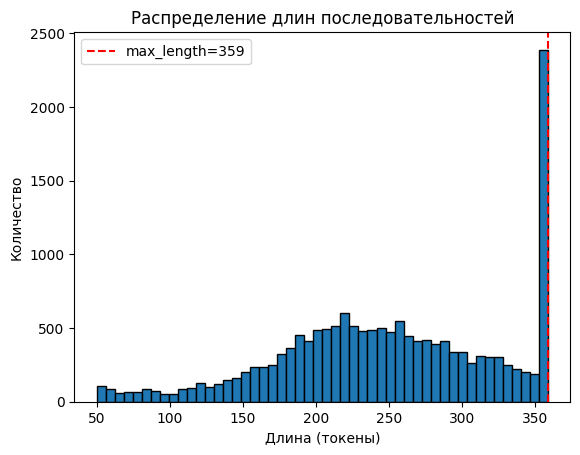

In [ ]:
# 2. Распределение длин
lengths = [len(ids) for ids in tokenized_data['input_ids']]
print(f"\nСтатистика длин:")
print(f"Среднее: {np.mean(lengths):.0f}")
print(f"Медиана: {np.median(lengths):.0f}")
print(f"Мин: {np.min(lengths)}, Макс: {np.max(lengths)}")
print(f"Обрезано (={context_length}): {sum(1 for l in lengths if l == context_length)} ({sum(1 for l in lengths if l == context_length)/len(lengths)*100:.1f}%)")

plt.hist(lengths, bins=50, edgecolor='black')
plt.xlabel('Длина (токены)')
plt.ylabel('Количество')
plt.title('Распределение длин последовательностей')
plt.axvline(context_length, color='red', linestyle='--', label=f'max_length={context_length}')
plt.legend()
plt.show()


| Метрика | ✅ Хорошо | ❌ Плохо |
|---------|-----------|----------|
| **Обрезка** | < 20% примеров | > 50% примеров |

**3. Восстановление текста (читаемость и смысл)**
- Взять несколько примеров: tokenizer.decode(ids) по input_ids.
- Проверить: нет ли артефактов, поломанных слов, странных пробелов/переносов; текст читаемый и близок к исходному.
- Хорошо: декодированный текст совпадает или почти совпадает с исходным (с учётом нормализации пробелов и т.п.).
- Плохо: пропадают части слов, появляются «» или мусор — токенизатор или кодировка подходят плохо.

In [ ]:
# 3. Проверка восстановления текста
print("\n=== Примеры декодирования ===")
for i in range(3):
    decoded = tokenizer.decode(tokenized_data['input_ids'][i], skip_special_tokens=True)
    print(f"\nПример {i+1}:")
    print(f"Длина: {len(tokenized_data['input_ids'][i])} токенов")
    print(f"Текст: {decoded[:200]}...")


=== Примеры декодирования ===

Пример 1:
Длина: 129 токенов
Текст: Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онколо...

Пример 2:
Длина: 220 токенов
Текст: Австрийские правоохранительные органы не представили доказательств нарушения российскими биатлонистами антидопинговых правил. Об этом сообщил посол России в Вене Дмитрий Любинский по итогам встречи уп...

Пример 3:
Длина: 184 токенов
Текст: Сотрудники социальной сети Instagram проанализировали поставленные пользователями смайлики, геолокации и хештеги и опубликовали итоги 2018 года. Об этом сообщается на официальном сайте Instagram. Таки...


| Метрика | ✅ Хорошо | ❌ Плохо |
|---------|-----------|----------|
| **Декодирование** | Читаемый текст | Артефакты, мусор |







**4. Соотношение «символы ↔ токены»**
- Для подвыборки: len(text) vs len(tokenizer.encode(text)).
- Среднее число символов на токен (или токенов на символ) — мера «сжатия».
- Полезно: сравнить разные токенизаторы или параметры; для одного языка/домена обычно ожидаем стабильное соотношение. Резкие отличия от ожидаемого могут указывать на проблемы.

In [ ]:
# 4. Соотношение символы/токены
sample_texts = dataset['text'][:100]
char_to_token_ratios = [len(text) / len(tokenizer.encode(text)) for text in sample_texts]
print(f"\n=== Соотношение символы/токены ===")
print(f"Среднее: {np.mean(char_to_token_ratios):.2f} символов на токен")
print(f"Диапазон: {np.min(char_to_token_ratios):.2f} - {np.max(char_to_token_ratios):.2f}")


=== Соотношение символы/токены ===
Среднее: 4.80 символов на токен
Диапазон: 2.81 - 5.64


| Метрика | ✅ Хорошо | ❌ Плохо |
|---------|-----------|----------|
| **Символы/токен** | 3-5 (русский) | < 2 или > 7 |

## **1.6. Разделение набора данных на тестовую и тренировочную выборки**

In [ ]:
# это другой ДРУГОЙ train_test_split!
# оказывается, train_test_split здесь не из sklearn, а из Huggingsface's метод объекта datasets из datasets - своя реализация
splits = tokenized_data.train_test_split(test_size=0.15)
train_data = splits["train"]
val_data = splits["test"]
# Результат => словарь вида splits = {
                                #     train: Dataset({
                                #         features: ['input_ids', 'attention_mask'],
                                #         num_rows: 1350
                                #     })
                                #     test: Dataset({
                                #         features: ['input_ids', 'attention_mask'],
                                #         num_rows: 150
                                #     })

# Количество примеров в каждом наборе
print(f"Тренировочных примеров: {len(train_data)}")
print(f"Валидационных примеров: {len(val_data)}")
print(f"Первый пример длина: {len(train_data[0]['input_ids'])}")
print(f"Первый пример текст (декодированный): {tokenizer.decode(train_data[0]['input_ids'][:50])}")

Тренировочных примеров: 13792
Валидационных примеров: 2435
Первый пример длина: 300
Первый пример текст (декодированный): С начала 2018 года в России подорожали крепкие спиртные напитки: водка, джин и абсент. Цены на них за первые семь месяцев года выросли на 6-8 процентов, пишут «Известия» со ссылкой на данные компании «Такском», собира


In [ ]:
splits

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 13792
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2435
    })
})

# **Задание 2. Дообучение модели** — 3 балла

## **2.1. Предварительная оценка качества** — 0.5 балла

Проверим качество генерации текста предобученной модели перед дообучением на нескольких примерах.




- выберем модель `ai-forever/rugpt3small_based_on_gpt`
- определим задачу `text-generation`
- установим оптимальные параметры: длина выходногно текста 100 токенов, температура 0.5, штраф за повторы 1.2, включим семплирование, чтобы получать разнообразные ответы.

**Промпты**

Так выбранная модель предназначена для продолжения заданной фразы, то построим промпты соответсвующим образом.

In [ ]:
# Фразы, которые предстоит продолжить текст с учетом того, что БУДЕТ дообучен на новостных текста

examples = [
    "Мы живем в удивительное время. В России все очень хорошо",
    "Возможно, вы удивитесь, но российская медицина самая лучшая в мире",
    "Россия - самая свободная страна в мире. Свобода в России - это"
    ]

In [ ]:
# Создание генератора текста при помощи пайплайна(задача, модель)
generator = pipeline('text-generation', model="ai-forever/rugpt3small_based_on_gpt2") # если прописывать модель здесь то токенайзер подтянется

# Генерируем ответы
for i, prompt in enumerate(examples, start=1):
    outputs = generator(
                       prompt,
                    #    max_length=50,         # — общая длина (промпт + генерация), т.к. промпт уже занимает ~30-40 токенов, поэтому генерируется только 10-20 токенов
                       max_new_tokens=110,       # длина выходного текста (только генерация, без промпта)
                       temperature=0.5,         # чем выше, тем более разнообразные ответы (0.9 — умеренно разнообразные; 0.5 — более консервативные; 1.0 и выше — более креативные, но могут быть менее связными)
                       repetition_penalty=1.2,  # штраф за повторение токенов (1.0 — без штрафа; >1.0 — с штрафом, чем выше, тем сильнее штраф)
                       do_sample=True,           # включаем сэмплирование, чтобы получать разнообразные ответы; если False — будет всегда одно и то же (самое вероятное) продолжение
                       )

    print(f"\n\n # {i} Prompt: {prompt}\nGenerated Text: {outputs[0]['generated_text']}\n")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'max_new_tokens', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_n



 # 1 Prompt: Мы живем в удивительное время. В России все очень хорошо
Generated Text: Мы живем в удивительное время. В России все очень хорошо, и я вижу это каждый день. Однако мне не хватает терпения, чтобы понять, что происходит с Россией.

— Я тоже так думаю… Я видел, как некоторые журналисты говорили о том, что Россия становится страной-агрессором. Но я хочу сказать: мы должны бороться за то, чтобы наше будущее было лучше для всех нас! Вот почему нам надо объединиться вокруг нашей страны — ведь у нее есть свои лидеры на международной арене. И я надеюсь, что наша страна будет развиваться по пути развития демократии, честного предпринимательства и цивилизованного



Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




 # 2 Prompt: Возможно, вы удивитесь, но российская медицина самая лучшая в мире
Generated Text: Возможно, вы удивитесь, но российская медицина самая лучшая в мире.  Ее используют для лечения людей с различными заболеваниями и даже смертельными исходами. 

 В Москве пройдет фестиваль "Веселые старты" 
 С 1 по 10 сентября 2013 года на территории ВДНХ состоится первый в России фестиваль детского творчества "Весёлые старты".  Фестиваль проводится при поддержке Департамента культуры города Москвы, Министерства образования и науки Российской Федерации. 
 На фестивале будет представлено более 300 детских площадок разного размера: от самых маленьких до больших.  Для детей будут организованы разнообразные мастер-классы, а также конкурсы творческих работ. 
 Конкурс



 # 3 Prompt: Россия - самая свободная страна в мире. Свобода в России - это
Generated Text: Россия - самая свободная страна в мире. Свобода в России - это свобода от всех ограничений и запретов, которые не позволяют нам жить своб

Мы видим, что модель не очень хорошо справляется с поставленными задачами.

**фиксируется:**

- ответы невпопад, порой сконструированы плохо.
- плохие ответы

## **2.2. Настройка процесса обучения** — 2 балла

Настроим параметры обучения (learning rate, batch size, количество эпох)

Обучим модель на нашем датасете в режиме полного дообучения.

Определим параметры обучения и **запустим дообучение**:


In [ ]:

model = AutoModelForCausalLM.from_pretrained(
    "ai-forever/rugpt3small_based_on_gpt2",
    tie_word_embeddings=False # отключаем связывание весов между эмбеддингами и головой, чтобы избежать ошибок при изменении vocab_size (хотя в нашем случае vocab_size не меняется, но это хорошая практика при дообучении)
)

# ПРОВЕРКА
print(f"Model vocab: {model.config.vocab_size}")
print(f"Tokenizer vocab: {tokenizer.vocab_size}")
print(f"Должны совпадать")
# Должны совпадать! Если НЕ совпадают:
if model.config.vocab_size != tokenizer.vocab_size:
    print("⚠️ ИСПРАВЛЯЕМ...")
    model.resize_token_embeddings(len(tokenizer))
    print(f"✅ Model vocab ПОСЛЕ resize: {model.config.vocab_size}")

data_collator = DataCollatorForLanguageModeling(   # Когда DataCollator ОБЯЗАТЕЛЕН:
    tokenizer=tokenizer,                            # Используем Trainer — DataCollator нужен в 99% случаев
    mlm=False  # для causal LM                      # Разная длина текстов — он делает динамический padding (эффективнее) батч паддится до max длины в батче, а не до max_length (меньше лишних вычислений)
)

# Настройки обучения чтобы считала побыстрее
training_args = TrainingArguments(   # Для увеличения скорости обучени
    output_dir="./output",           # Директория сохранения результатов
    per_device_train_batch_size=16,   # Увеличить с 2 до 8     # Сколько примеров обрабатывать за один шаг на одном устройстве (больше -> быстрее; Меньше (1, 2) → меньше памяти, медленнее; градиент шумнее.)
    per_device_eval_batch_size=32,   # Увеличить с 16 до 32   # Размер батча на валидации. На eval градиенты не считаются, памяти нужно меньше.  (больше -> быстрее) Уменьшать при нехватке памяти.
    gradient_accumulation_steps=4,   # Уменьшить с 4 до 2     # Сколько шагов накапливать градиент перед обновлением весов. Больше (8, 16) → стабильнее градиент, ближе к большому батчу
    warmup_steps=200,                 # Увеличить с 50 до 100  # Прогрев: Число шагов, на которых learning rate линейно растёт от 0 до заданного lr. Больше → осторожнее старт, меньше риск «сломать» предобученные веса в начале.
    save_strategy="steps",              # epoch - сохранять реже # Сохранение чекпоинтов: "steps" — сохранять по шагам (дольше обучение и возобновления с последнего чекпоинта); "epoch" — раз в эпоху; "no" — не сохранять.
    save_steps=100,                  # Сохранять модель каждые 500 шагов: Больше → реже сохранения, если мало места на диске, но при падении теряется больше.
    num_train_epochs=10,              # Уменьшить с 2 до 1     # Сколько раз пройти весь обучающий датасет: Больше (3, 5) → модель сильнее подстраивается под данные - риск переобучения; Меньше (1) → меньше переобучение, но может недоборать качество.
    weight_decay=0.03,                # Уменьшить с 0.1 до 0.01 # L2-регуляризация весов (аналог штрафа за большие веса).
    lr_scheduler_type="cosine",      # linear - более быстрый #"cosine" — плавное уменьшение по косинусу до конца обучения.
    optim="adamw_torch",             # Оптимизатор: AdamW (Adam + weight decay). Стандартный выбор для трансформеров.
    learning_rate=5e-5,              # 1e-3 быстрее, чем 5e-4 ... Начальный learning rate после warmup (0.0005). Больше (1e-3, 2e-3) → быстрее обучение, Меньше (1e-4, 2e-4) → стабильнее, но обучение может быть медленным или «застрять».
    fp16=torch.cuda.is_available(),  # None # Использовать float16 на GPU, если он есть: экономия памяти и ускорение. На CPU не используется.
    dataloader_num_workers=0,             # 4 - ошибка, Параллельная загрузка данных
    remove_unused_columns=False,
    logging_steps=50,                     # Реже логирование
    eval_strategy="steps",           # Было "epoch" → чаще проверяем
    eval_steps=100,                   # Оценка каждые 100 шагов
    save_total_limit=2,
    load_best_model_at_end=True,        # загрузить лучшую модель
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    # max_steps=1000,                       # Ограничить количество шагов
)

# Обучаем модель
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_data,    # .select(range(min(1000, len(train_data)))),
    eval_dataset=val_data,       # автоматически считает perplexity после каждой эпохи
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model vocab: 50264
Tokenizer vocab: 50257
Должны совпадать
⚠️ ИСПРАВЛЯЕМ...
✅ Model vocab ПОСЛЕ resize: 50257


In [ ]:
# Начинаем обучение
trainer.train()

Step,Training Loss,Validation Loss
100,3.059557,2.829563
200,2.896086,2.758499
300,2.790529,2.723259
400,2.755316,2.695499
500,2.642852,2.683102
600,2.630682,2.664906
700,2.524267,2.663138
800,2.540612,2.646342
900,2.461091,2.650140
1000,2.448664,2.636545


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1700, training_loss=2.5772067889045265, metrics={'train_runtime': 959.3189, 'train_samples_per_second': 143.769, 'train_steps_per_second': 2.252, 'total_flos': 2.8756484871561216e+16, 'train_loss': 2.5772067889045265, 'epoch': 7.872389791183295})

Training Loss должен быть 1-2.

## **2.3. Оценка качества обучения** — 0.5 балла



Посмотрим на генерацию.

In [ ]:
# 3. Посмотрите на генерацию
generator = pipeline('text-generation', model="./output/final_model")
output = generator("Мы живем в удивительное время", max_new_tokens=50)
print(output)
# Если генерация хорошая → всё ОК
# Если бессмыслица → переобучение

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Мы живем в удивительное время. Об этом свидетельствует история нашей страны. А в том, что мы живем в удивительное время, — это я считаю одним из лучших в истории. И если бы не было этого уникального времени — я бы его упустил», — отметил президент Федерации спортивного ве'}]


В целом, вроде нормально.

**Считаем Perplexity.**

In [ ]:
# Считаем Perplexity
eval_results = trainer.evaluate(eval_dataset=val_data)

print(f"Loss: {eval_results['eval_loss']:.4f}")
print(f"Perplexity: {math.exp(eval_results['eval_loss']):.4f}")


Loss: 2.6250
Perplexity: 13.8052


**Что означает Perplexity = 13.8?**

Модель в среднем колеблется между 13-14 вариантами следующего слова

### Целевые значения:
- **Отлично:** Perplexity < 5
- **Хорошо:** Perplexity 5-10
- **Приемлемо:** Perplexity 10-15

Чем ниже **perplexity**, тем лучше модель справляется с задачей генерации текста.

Результат обучения:

| Метрика | Начало (step 100) | Конец (step 1700) | Изменение |
|---------|-------------------|-------------------|-----------|
| **Train Loss** | 3.06 | 2.31 | ↓ **24.5%** |
| **Val Loss** | 2.83 | 2.63 | ↓ **7.1%** |





| Параметр | Старая модель | Новая модель | Улучшение |
|----------|---------------|--------------|-----------|
| **Датасет** | 5,000 | 15,000 | +200% |
| **Epochs** | 3 | 7 | +133% |
| **Final Val Loss** | 2.68 | 2.63 | ↓ 1.9% |
| **Perplexity** | 14.60 | 13.80 | ↓ 5.5% |
| **Train Loss** | 2.55 | 2.31 | ↓ 9.4% |


✅ Train Loss падает стабильно → модель учится

✅ Val Loss падает медленнее → нормально для fine-tuning

✅ Perplexity снизился с ~17 до 13.8 → текст стал предсказуемее

✅ Нет переобучения — Val Loss не растёт

✅ Стабильное снижение — без резких скачков

✅ Небольшой gap — Train Loss (2.31) vs Val Loss (2.63) = 0.32 (норма)

**Проверим качество генерации после дообучения на нескольких примерах.**

- повторим те же настройки, которые были (длина текста 110, температура 0.5, штраф за повторения, семплирование).

In [ ]:
# Создаём новый генератор текста с дообученной моделью
new_generator = pipeline('text-generation', model="./output/final_model", tokenizer=tokenizer) # дописываем вручную токенайзер потому что не с хагинфейса модель, а с компа

# Тестируем новую модель на тех же примерах
for i, prompt in enumerate(examples, start=1):
    outputs = new_generator(
                       prompt,
                       max_length=None,         # — общая длина (промпт + генерация), т.к. промпт уже занимает ~30-40 токенов, поэтому генерируется только 10-20 токенов
                       max_new_tokens=110,       # длина выходного текста (только генерация, без промпта)
                       temperature=0.5,         # чем выше, тем более разнообразные ответы (0.9 — умеренно разнообразные; 0.5 — более консервативные; 1.0 и выше — более креативные, но могут быть менее связными)
                       repetition_penalty=1.2,  # штраф за повторение токенов (1.0 — без штрафа; >1.0 — с штрафом, чем выше, тем сильнее штраф)
                       do_sample=True,           # включаем сэмплирование, чтобы получать разнообразные ответы; если False — будет всегда одно и то же (самое вероятное) продолжение
                       )
    print(f"\n\n # {i} Prompt: {prompt}\nGenerated Text: {outputs[0]['generated_text']}\n")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




 # 1 Prompt: Мы живем в удивительное время. В России все очень хорошо
Generated Text: Мы живем в удивительное время. В России все очень хорошо, но есть проблемы: в стране не хватает денег на жилье и на медицину, а у нас нет средств даже на еду», — цитирует его «Интерфакс» со ссылкой на источник в правоохранительных органах. По словам собеседника агентства, из-за нехватки денег правительство решило отказаться от субсидирования ипотеки для застройщиков жилья. «Безусловно, мы должны были бы сделать такую меру поддержки застройщикам, чтобы они могли снизить ставки по кредитам для них», — пояснил собеседник агентства. Он также добавил, что некоторые банки начали закупать более дешевые квартиры, чем те,



Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




 # 2 Prompt: Возможно, вы удивитесь, но российская медицина самая лучшая в мире
Generated Text: Возможно, вы удивитесь, но российская медицина самая лучшая в мире. Об этом заявил глава Роспотребнадзора Геннадий Онищенко на заседании Совета при президенте РФ по развитию гражданского общества и правам человека (СПЧ) Михаил Федотов, передает ТАСС. «На сегодняшний день мы стоим у истоков российской медицины — это самое лучшее достижение отечественной науки за последние годы», — сказал он. По словам министра здравоохранения Вероники Скворцовой, российские специалисты уже достигли больших успехов в лечении онкологических заболеваний. Она также отметила, что в России есть большое количество людей с хроническими заболеваниями, которые не чувствуют себя здоровыми. Она добавила, что некоторые



 # 3 Prompt: Россия - самая свободная страна в мире. Свобода в России - это
Generated Text: Россия - самая свободная страна в мире. Свобода в России - это не только возможность управлять своей жизнью, 

**Результаты сравнения:**

Тексты стали генерироваться гораздо лучше и более связными, более осмысленно.

После обучения сохраняем и модель и токенайзер.

In [ ]:
# Сохраняем дообученную модель и токенайзер
model.save_pretrained("./output/final_model")
tokenizer.save_pretrained("./output/final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./output/final_model/tokenizer_config.json',
 './output/final_model/tokenizer.json')

Хоть токенайзер не меняется в процессе обучения, но так принято сохранять:

- на случай передачи кому-то (человек просто загружает и заработает)
- для pipeline (он автоматически ищет токенайзер в той же папке)
- для документации (явно показывает, какой токенайзер использовался с этой моделью)

it's a best practice.

# **Задание 3. Сэмплирование** — 5 баллов





Создадим сэмплер.

In [ ]:
class Sampler:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def _generate_with_min_p(self, input_ids, min_p, max_new_tokens=50, temperature=1.0, **kwargs):
        """Ручная генерация с min_p фильтрацией"""
        self.model.eval()
        generated = input_ids.clone()

        with torch.no_grad():
            for _ in range(max_new_tokens):
                outputs = self.model(generated)
                logits = outputs.logits[0, -1, :] / temperature

                # Min-p фильтрация
                probs = torch.softmax(logits, dim=-1)
                max_prob = probs.max()
                min_threshold = min_p * max_prob

                # Убираем токены ниже порога
                mask = probs >= min_threshold
                filtered_logits = logits.clone()
                filtered_logits[~mask] = -float('inf')

                # Сэмплируем
                filtered_probs = torch.softmax(filtered_logits, dim=-1)
                next_token_id = torch.multinomial(filtered_probs, num_samples=1)

                generated = torch.cat([generated, next_token_id.unsqueeze(0)], dim=1)

                if next_token_id.item() == self.tokenizer.eos_token_id:
                    break

        return [self.tokenizer.decode(generated[0], skip_special_tokens=True)]


    def generate(self, prompt, min_p=None, **kwargs):
        """Обёртка над model.generate() с дефолтными параметрами"""
        input_ids = self.tokenizer.encode(prompt, return_tensors='pt').to(self.device)

        # Если min_p задан — используем ручную генерацию
        if min_p is not None:
            return self._generate_with_min_p(input_ids, min_p, **kwargs)

        with torch.no_grad():
            outputs = self.model.generate(input_ids, **kwargs)

        return [self.tokenizer.decode(out, skip_special_tokens=True) for out in outputs]



    def visualize_temperature_effect(self, prompt, temperatures):
        """Единственная кастомная функция — визуализация"""
        self.model.eval()  # Переводим модель в режим оценки

        # Токенизация
        input_ids = self.tokenizer.encode(prompt, return_tensors='pt')  # Преобразуем промпт в токены

        # Проверка: если пустой - значит проблема с токенайзером или промптом
        if input_ids.shape[1] == 0:  # Если токенайзер вернул пустой тензор
            print(f"Промпт: '{prompt}'")  # Выводим промпт для отладки
            print(f"Длина промпта: {len(prompt)}")  # Выводим длину промпта
            print(f"Токенайзер: {self.tokenizer}")  # Выводим информацию о токенайзере
            raise ValueError("Токенайзер вернул пустой input_ids. Проверьте промпт и токенайзер.")  # Выбрасываем ошибку

        input_ids = input_ids.to(self.device)  # Переносим токены на устройство (GPU/CPU)

        with torch.no_grad():  # Отключаем вычисление градиентов
            outputs = self.model(input_ids)  # Прогоняем промпт через модель
            logits = outputs.logits[0, -1, :]  # Берем логиты для последнего токена (предсказание следующего слова)

        top_k = 20  # Берем 20 самых вероятных токенов
        top_logits, top_indices = torch.topk(logits, top_k)  # Находим top_k логитов и их индексы

        fig, axes = plt.subplots(1, len(temperatures), figsize=(15, 5))  # Создаем графики для каждой температуры

        for idx, temp in enumerate(temperatures):  # Для каждой температуры
            scaled_logits = top_logits / temp if temp != 0 else top_logits  # Применяем температуру к логитам
            probs = F.softmax(scaled_logits, dim=-1).cpu().numpy()  # Преобразуем в вероятности и переносим на CPU

            tokens = [self.tokenizer.decode([i]) for i in top_indices.cpu()]  # Декодируем токены в текст

            ax = axes[idx] if len(temperatures) > 1 else axes  # Выбираем нужный subplot
            ax.bar(range(len(probs[:10])), probs[:10])  # Рисуем столбчатую диаграмму для 10 токенов
            ax.set_xlabel('Token Index')
            ax.set_ylabel('Probability')
            ax.set_title(f'Temperature = {temp}')
            ax.set_xticks(range(len(probs[:10])))
            ax.set_xticklabels([f'{t[:8]}...' if len(t) > 8 else t  # Обрезаем длинные токены
                                for t in tokens[:10]], rotation=45, ha='right')

        plt.tight_layout()  # Автоматически подгоняем расположение графиков
        plt.show()  # Показываем графики

In [ ]:
sampler = Sampler(model, tokenizer)

In [ ]:
# # Загружаем дообученную модель
# model = GPT2LMHeadModel.from_pretrained("./output/final_model")

# # Загружаем токенайзер из ИСХОДНОЙ модели
# tokenizer = GPT2Tokenizer.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")

## **Эксперименты с сэмплированием** — 3 балла


Необходимо выбрать и протестируовать как минимум 4 различных комбинации параметров сэмплирования.

Варианты параметров:

- **Top_k**: Оставляет только K самых вероятных токенов, остальные отбрасывает
- **Top_P**: Выбирает минимальный набор токенов, чья суммарная вероятность не превышает заданную (≥ P).
- **Min_P**: Отбрасывает токены с вероятностью меньше min_p × (вероятность самого вероятного токена).


Создаем единый промпт

In [ ]:
prompt = examples[0]

## **3.1. Greedy decoding**

- **Greedy decoding**: **показать базовую генерацию без вариаций. (установить do_sample=False)**

Greedy decoding = жадный декодинг = всегда выбирать самый вероятный токен

Всегда одинаковый результат, потому что top_k = 1.

In [ ]:
print("=== 1. Greedy decoding ===")
print(sampler.generate(prompt, max_new_tokens=50, do_sample=False)[0])

=== 1. Greedy decoding ===
Мы живем в удивительное время. В России все очень хорошо, но в то же время мы не можем жить в условиях, когда все друг друга ненавидят. Мы живем в мире, где все друг друга ненавидят, и в то же время мы не можем жить в мире, где все друг друга ненавидят


# **3.2. Temperature sampling**


- **Temperature sampling**: **исследование роли температуры в разнообразии генерации.**

Выставим разные значения temperature - меньше 1, 1, больше 1...

Ваизуализируем разницу температур: как от изменения значения температуры меняется распределение токенов.

In [ ]:
print("\n=== 2. Temperature = 0.5 ===")
print(sampler.generate(prompt, max_new_tokens=50, temperature=0.5, do_sample=True)[0])


=== 2. Temperature = 0.5 ===
Мы живем в удивительное время. В России все очень хорошо, и мы, конечно, не можем не радоваться этому. Но, к сожалению, мы еще не готовы к серьезным изменениям. В ближайшие годы мы будем вынуждены отказаться от ряда наших инициатив, и, к сожалению, все это связано с тем, что мы


In [ ]:
print("\n=== 3. Temperature = 1.5 ===")
print(sampler.generate(prompt, max_new_tokens=50, temperature=1.5, do_sample=True)[0])


=== 3. Temperature = 1.5 ===
Мы живем в удивительное время. В России все очень хорошо, но государство тормозит свои реформы, потому что мы уже устали следить за благосостоянием народов, которое является не только экономическим фактором, но и главным драйвером мировой безопасности. Но наше правительство не обращает должного внимания на то, что происходит в мире в целом


## **3.3. Top_k**

- **Top-k sampling**: оценка влияния верхнего квантиля на разнообразие и стиль текста.

 Выставим разные значения top_k

In [ ]:
print("\n=== 4. Top-k = 10 ===")
print(sampler.generate(prompt, max_new_tokens=50, top_k=10, do_sample=True)[0])



=== 4. Top-k = 10 ===
Мы живем в удивительное время. В России все очень хорошо, но в стране идет гражданская война, и она не прекращается и в ближайшем будущем. И мы очень переживаем за тех, кто пострадал. Мы очень любим своих детей и любим своих внуков, которые уже взрослые. И сейчас мы тоже переживаем за


In [ ]:
print("\n=== 5. Top-k = 50 ===")
print(sampler.generate(prompt, max_new_tokens=50, top_k=50, do_sample=True)[0])


=== 5. Top-k = 50 ===
Мы живем в удивительное время. В России все очень хорошо. Но в последнее время россияне не очень хотят ввязываться в европейское образование. Я так считаю, что у нас, в отличие от США, с детства не складывается такой возможности, что на Западе людям нет места. В основном, наши студенты —


In [ ]:
print("\n=== 6. Top-k = 100 ===")
print(sampler.generate(prompt, max_new_tokens=50, top_k=100, do_sample=True)[0])


=== 6. Top-k = 100 ===
Мы живем в удивительное время. В России все очень хорошо, и мы понимаем, насколько важным является наше благополучие, — комментирует слова президента России Владимира Путина министр по делам Северного Кавказа Александр Хлопонин. — У нас много хороших друзей, и мы любим наших врагов, причем всегда за хорошие поступки. Они не знают


## **3.4. Top_p**

- **Top-p (nucleus) sampling**: определение оптимального уровня отсечения вероятностного распределения  

Выставим разные значения top_p.

In [ ]:
print("\n=== 7. Top-p = 0.8 ===")
print(sampler.generate(prompt, max_new_tokens=50, top_p=0.8, do_sample=True)[0])


=== 7. Top-p = 0.8 ===
Мы живем в удивительное время. В России все очень хорошо и даже с натяжкой можно говорить о том, что будет происходить с нашей страной, если на ее территории начнется реализация какого-то проекта, который изменит нашу жизнь. Все очень хорошо. В России есть богатые, влиятельные и влиятельные люди, которые


In [ ]:
print("\n=== 8. Top-p = 0.95 ===")
print(sampler.generate(prompt, max_new_tokens=50, top_p=0.95, do_sample=True)[0])


=== 8. Top-p = 0.95 ===
Мы живем в удивительное время. В России все очень хорошо. Мы в своем большинстве хотим быть цивилизованными. Наши проблемы и опасения не влияют на политику государства. Мы не считаем политику глупой. Наша задача понять и принять решение и принять адекватные меры к изменению жизни и развитию», — заявил в интервью «Россий


## **3.5. Min-p**

- **Min-p sampling**: изучение минимального порогового уровня вероятностей.

Используем параметр min_p.

 **Проблема**: min_p нет в transformers

`min_p` — это кастомный параметр, которого НЕТ в стандартном `model.generate()`.

мы написали свой.

In [ ]:
print("\n=== Min-p sampling ===")
for min_p_val in [0.05, 0.1, 0.2]:
    print(f"\n--- min_p = {min_p_val} ---")
    print(sampler.generate(prompt, min_p=min_p_val, max_new_tokens=50)[0])


=== Min-p sampling ===

--- min_p = 0.05 ---
Мы живем в удивительное время. В России все очень хорошо, и мы не хотим, чтобы в будущем случилось что-то плохое, поэтому мы и хотим жить хорошо. Мы готовы сделать это, несмотря на все сложности, и готовы это делать. Потому что нам нужны перемены», — заявил глава правительства Владимир Путин на

--- min_p = 0.1 ---
Мы живем в удивительное время. В России все очень хорошо, и, конечно, мы должны радоваться этому, но в то же время жить в этой ситуации, конечно, не так хорошо, как хотелось бы, мы не должны расслабляться и расслабляться», — считает депутат Госдумы Андрей Турчак. По его словам

--- min_p = 0.2 ---
Мы живем в удивительное время. В России все очень хорошо, но в последнее время в стране наблюдается тенденция к ухудшению отношений с Западом. Такое мнение высказал глава Центра политической конъюнктуры Алексей Мухин, передает ТАСС. «В последнее время в стране наблюдается тенденция к ухудшению отношений с Западом. Мы живем в удивительно

## **3.6. Beam search**

- **Beam search**: выявление преимуществ детерминированного подхода. (установите num_beams > 1)

In [ ]:
print("\n=== 9. Beam search (num_beams=2) ===")
print(sampler.generate(prompt, max_new_tokens=50, num_beams=2, do_sample=False)[0])


=== 9. Beam search (num_beams=2) ===
Мы живем в удивительное время. В России все очень хорошо, но в то же время мы не можем себе позволить роскошь жить в бедности. Об этом заявил президент России Владимир Путин, выступая на заседании дискуссионного клуба «Валдай», передает РИА Новости. «Мы живем в удивительное время, когда все очень хорошо


In [ ]:
print("\n=== 10. Beam search (num_beams=4) ===")
print(sampler.generate(prompt, max_new_tokens=50, num_beams=4, do_sample=False)[0])


=== 10. Beam search (num_beams=4) ===
Мы живем в удивительное время. В России все очень хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все


In [ ]:
print("\n=== 11. Beam search (num_beams=8) ===")
print(sampler.generate(prompt, max_new_tokens=50, num_beams=8, do_sample=False)[0])


=== 11. Beam search (num_beams=8) ===
Мы живем в удивительное время. В России все очень хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все хорошо, все


## **3.7. NB:взаимодействие параметров (например, как top_p работает с top_k)**




In [ ]:
print("\n=== 11. Взаимодействие ===")
print(sampler.generate(prompt, top_p=0.8, top_k=3, do_sample=False)[0])


=== 11. Взаимодействие ===
Мы живем в удивительное время. В России все очень хорошо, но в мире все плохо. Мы живем в удивительное время, и я хочу, чтобы это было


In [ ]:
print("\n=== 12. Взаимодействие ===")
print(sampler.generate(prompt, top_p=0.3, top_k=5, do_sample=False)[0])


=== 12. Взаимодействие ===
Мы живем в удивительное время. В России все очень хорошо, но в мире все плохо. Мы живем в удивительное время, и я хочу, чтобы это было


## **3.8. Анализ результатов** — 2 балла

Проведем анализ влияния получившихся комбинаций на:

- Грамматичность и связность генерируемого текста
- Креативность и разнообразие генерации
- Соответствие стилю исходного датасета
- Наличие повторений и прочих артефактов генерации
- Определим оптимальные параметры для нашей задачи генерации и обоснуем наш выбор.

**Анализ результатов:**

**1. Greedy Decoding: **

- `do_sample=False`: текст показался странным и противоречивым. Вероятно, подходит для строгих технических или научных текстов. Соответсвенно следует  обучать но соответсвующих примерах.

**2. Temperature Sampling:**

- `Температура < 1`: Меньшее значение лучше, но все равно не очень хорошо, вероятно, надо посикать среди минимальных.

- `Температура 1.5`: Повышается бессвязность, появляются грамматические ошибки и потеря смысла.

**Заключение**: Оптимальной температурой считается значение около 0.5 и меньше.

**3. Top-K Sampling:**

- `K = 10`: Выглядит странно.

- K = 50`: выглядит странно.

- `K = 100`: Показал наилучший результат.

**Заключение**: K ≈ 100 кажется наиболее оптимальным выбором.

**4. Top-P Sampling:**

- `P = 0.8`: Меньше связности.

- `P = 0.95`: Более связно получилось.

**Заключение**: 0.95 - представляется лучшим вариантом.

**5. Min-P Sampling:**

- `Низкое минимальное значение:` Хорошо снижает вероятность редких событий, улучшает общий уровень грамотности.

- `Высокое минимальное значение:` Сокращает пространство возможных выборов,больше генерирует бессмыслицы.

**Заключение:** Наибольшее значение 2 - дало наи лучший результат.

**6. Beam Search:**

- `Beams = 2:` Быстрая генерация, хорошие результаты для коротких текстов.

- `Beams = 4`: Много повторов "Всё хорошо"

- `Beams = 8`: Много повторов "Всё хорошо"

**Заключение:** Лучшим числом является 2.